# Filtrado con 4 líneas — corrijo el modelo de dos líneas

En mi notebook anterior (`Simulaciones_filtros.ipynb`) modelé el filtrado plegando el circuito diferencial en una sola escalera equivalente, con dos líneas: la que lleva la corriente y también "mide" la tensión en el mismo par de nodos. Pero el arreglo real tiene **cuatro** líneas: el par de corriente (que polariza la juntura) y el par de sensado (que va al nanovoltímetro), y se juntan recién en los dos bornes de la juntura.

Por las resistencias serie del par de sensado casi no circula corriente, porque termina en el voltímetro de 1GΩ. Pero por sus **capacitores** sí — y el último de ellos está a solo 66Ω (3×22Ω) del nodo de la juntura, prácticamente en paralelo con los capacitores del par de corriente. Ese camino extra de fuga capacitiva es lo que quiero cuantificar acá.

No toco el notebook anterior — éste lo complementa. Y esta vez armo el circuito como un **solver nodal general**, en vez de cablear una escalera a mano: le paso una lista de elementos (tipo, nodo A, nodo B, valor) y arma la matriz de admitancias sola. La razón es concreta: más adelante voy a agregar inductancias parásitas en serie con los capacitores y capacidades parásitas en paralelo con las resistencias — en un solver así, eso es agregar un elemento a la lista; en una escalera cableada a mano habría que rehacer todo de nuevo.

Trabajo con **excitación de corriente** (el Keithley 6620 es una fuente de corriente, no de tensión), y con la **masa flotante**: los únicos caminos a masa son los que tiene el circuito real (los capacitores de ambiente), sin agregar ningún camino artificial extra. Aterrar a mano un borne de la juntura abriría caminos de modo común por esos mismos capacitores que no están en el circuito real — ese caso lo dejo aparte, no lo mezclo acá.

## Paso 1: el motor — análisis nodal general

La idea del análisis nodal es simple: cada nodo del circuito tiene una tensión desconocida (menos uno, que uso de referencia — "masa", $V=0$ por definición). Para cada elemento (resistencia o capacitor) entre los nodos A y B, con admitancia $y$ ($=1/R$ para una resistencia, $=j\omega C$ para un capacitor en fasores), "estampo" esa admitancia en una matriz $Y$:

- sumo $y$ en la diagonal, en las posiciones (A,A) y (B,B) — la corriente que sale de cada nodo hacia ese elemento,
- resto $y$ en las posiciones cruzadas (A,B) y (B,A) — la corriente que sale de A por ese elemento es la misma que entra a B.

Con la matriz completa armada, resuelvo $Y \cdot V = I$, donde $I$ es el vector de corrientes inyectadas por las fuentes externas. Como todo el circuito es lineal, si inyecto exactamente 1A la solución $V$ que sale es directamente la **impedancia de transferencia en Ohm** — no hace falta barrer la corriente ni dividir después.

No hay fuentes de tensión en este circuito (ni el voltímetro ni la fuente de corriente lo son), así que alcanza con análisis nodal puro, sin las variables de rama extra que hacen falta en el método más general (MNA) cuando hay fuentes de tensión de por medio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
from scipy import optimize, linalg

In [2]:
def nodos_de(elementos, extra=()):
    """Arma el diccionario nodo -> indice de fila/columna en la matriz.
    'masa' no entra: es la referencia, V=0 por definicion."""
    nodos = set()
    for (tipo, a, b, valor) in elementos:
        nodos.add(a); nodos.add(b)
    nodos.update(extra)
    nodos.discard('masa')
    return {n: i for i, n in enumerate(sorted(nodos))}


def resolver_ac(elementos, idx, fuente, frecuencia_Hz):
    """elementos: lista de (tipo, nodoA, nodoB, valor), tipo en {'R','C'}.
    fuente=(desde,hacia): inyecta 1A (fasor) que ENTRA por 'hacia' y SALE por 'desde'.
    Devuelve dict nodo -> tension compleja (con 1A inyectado, V = Z en Ohm)."""
    n = len(idx)
    omega = 2.0 * np.pi * frecuencia_Hz
    Y = np.zeros((n, n), dtype=complex)
    for (tipo, a, b, valor) in elementos:
        if tipo == 'R':
            y = 1.0 / valor
        elif tipo == 'C':
            y = 1j * omega * valor
        else:
            raise ValueError(f"tipo de elemento desconocido: {tipo}")
        ia, ib = idx.get(a), idx.get(b)
        if ia is not None:
            Y[ia, ia] += y
        if ib is not None:
            Y[ib, ib] += y
        if ia is not None and ib is not None:
            Y[ia, ib] -= y
            Y[ib, ia] -= y

    I = np.zeros(n, dtype=complex)
    desde, hacia = fuente
    if desde in idx:
        I[idx[desde]] -= 1.0
    if hacia in idx:
        I[idx[hacia]] += 1.0

    V = np.linalg.solve(Y, I)
    return {nodo: V[i] for nodo, i in idx.items()}

### Valido el motor antes de aplicarlo al circuito real

Antes de armar la topología de 4 líneas quiero estar segura de que el solver nodal en sí está bien escrito. Lo pruebo contra dos circuitos chiquitos donde puedo calcular la impedancia a mano, sin reusar nada del código del solver: un RC paralelo simple ($Z=R/(1+j\omega RC)$) y una escalera de dos etapas con carga, resuelta por reducción de impedancias en cascada.

In [3]:
# Test A: RC paralelo simple
R_t, C_t = 1234.0, 3.3e-9
elem_A = [('R', 'a', 'masa', R_t), ('C', 'a', 'masa', C_t)]
idx_A = nodos_de(elem_A)
freqs_A = np.logspace(1, 8, 25)
Z_solver_A = np.array([resolver_ac(elem_A, idx_A, ('masa', 'a'), f)['a'] for f in freqs_A])
Z_analitico_A = R_t / (1 + 1j * 2*np.pi*freqs_A * R_t * C_t)
err_A = np.max(np.abs(Z_solver_A - Z_analitico_A) / np.abs(Z_analitico_A))
print(f"Test A (RC paralelo):        error relativo maximo = {err_A:.2e}")

# Test B: escalera de 2 etapas + carga, contra impedancias en cascada calculadas aparte
Rt1, Ct1, Rt2, Ct2, Rl = 100.0, 10e-9, 220.0, 4.7e-9, 500.0
elem_B = [('R', 'in', 'n1', Rt1), ('C', 'n1', 'masa', Ct1), ('R', 'n1', 'n2', Rt2),
          ('C', 'n2', 'masa', Ct2), ('R', 'n2', 'masa', Rl)]
idx_B = nodos_de(elem_B)

def Z_cascada_manual(f):
    w = 2*np.pi*f
    Z_C2 = 1/(1j*w*Ct2)
    Z_shunt2 = 1/(1/Z_C2 + 1/Rl)
    Z_der_n1 = Rt2 + Z_shunt2
    Z_C1 = 1/(1j*w*Ct1)
    Z_shunt1 = 1/(1/Z_C1 + 1/Z_der_n1)
    return Rt1 + Z_shunt1

freqs_B = np.logspace(1, 7, 20)
Z_solver_B = np.array([resolver_ac(elem_B, idx_B, ('masa', 'in'), f)['in'] for f in freqs_B])
Z_manual_B = np.array([Z_cascada_manual(f) for f in freqs_B])
err_B = np.max(np.abs(Z_solver_B - Z_manual_B) / np.abs(Z_manual_B))
print(f"Test B (escalera 2 etapas):  error relativo maximo = {err_B:.2e}")

Test A (RC paralelo):        error relativo maximo = 3.53e-16
Test B (escalera 2 etapas):  error relativo maximo = 4.48e-16


Los dos dan error de precisión de punto flotante ($10^{-16}$), no un error de método — el motor arma bien la matriz de admitancias. Con esto ya puedo confiar en el solver para la topología real.

## Paso 2: la topología física, 4 líneas sin plegar

Nombro los nodos así, para cada una de las cuatro líneas:

```
par de corriente, línea + :   i0 - i1 - i2 - i3 - i4 - jp
par de corriente, línea - :   j0 - j1 - j2 - j3 - j4 - jn
par de sensado,   línea + :   v0 - v1 - v2 - v3 - v4 - jp
par de sensado,   línea - :   w0 - w1 - w2 - w3 - w4 - jn
```

En cada línea van las mismas cinco resistencias en serie: $R_{ta}$-$R_{ta}$-$R_{cry}$-$R_{cry}$-$R_{cry}$ (la última es la resistencia de desacople). Los capacitores de ambiente (2,2µF) van a masa, uno por nodo intermedio de cada línea. Los capacitores criogénicos (47nF) **no** van a masa — cruzan entre las dos líneas de cada par (corriente e- corriente, y sensado-sensado), porque el criostato está eléctricamente aislado y el filtro ahí es diferencial.

En los bornes de la juntura: $R_J$ (el parámetro que barro) y $C_J$=50pF, ambos entre `jp` y `jn`. El voltímetro (1GΩ) va entre `v0` y `w0`. La fuente de corriente inyecta entre `i0` y `j0`.

In [4]:
def construir_circuito(R_ta, C_ta, R_cry, C_cry, R_J, C_J, R_volt, con_CJ=True):
    """Arma la lista de elementos del arreglo experimental: las 4 lineas
    (par de corriente i,j + par de sensado v,w), como el arreglo real."""
    elementos = []
    termina_en = {'i': 'jp', 'j': 'jn', 'v': 'jp', 'w': 'jn'}

    for x in ['i', 'j', 'v', 'w']:
        n0, n1, n2, n3, n4 = f'{x}0', f'{x}1', f'{x}2', f'{x}3', f'{x}4'
        elementos += [
            ('R', n0, n1, R_ta), ('R', n1, n2, R_ta),
            ('R', n2, n3, R_cry), ('R', n3, n4, R_cry),
            ('R', n4, termina_en[x], R_cry),
        ]
        elementos += [('C', n1, 'masa', C_ta), ('C', n2, 'masa', C_ta)]

    elementos += [('C', 'i3', 'j3', C_cry), ('C', 'i4', 'j4', C_cry)]
    elementos += [('C', 'v3', 'w3', C_cry), ('C', 'v4', 'w4', C_cry)]
    elementos += [('R', 'v0', 'w0', R_volt)]

    elementos += [('R', 'jp', 'jn', R_J)]
    if con_CJ and C_J > 0:
        elementos += [('C', 'jp', 'jn', C_J)]

    # (desde,hacia)=('j0','i0'): +I entra al circuito por i0 y vuelve por j0 -> recorre
    # la linea i hasta jp, cruza R_J de jp a jn, vuelve por la linea j -> V(jp)-V(jn)=+I*R_J en DC.
    fuente = ('j0', 'i0')
    return elementos, fuente


def impedancia(elementos, fuente, freqs_Hz, nodo_pos, nodo_neg):
    idx = nodos_de(elementos)
    Z = np.zeros(len(freqs_Hz), dtype=complex)
    for k, f in enumerate(freqs_Hz):
        V = resolver_ac(elementos, idx, fuente, f)
        Z[k] = V[nodo_pos] - V[nodo_neg]
    return Z


R_TA, C_TA = 150.0, 2.2e-6      # canal 1 de la tabla 5.1
R_CRY, C_CRY = 22.0, 47e-9
C_J = 50e-12
R_VOLT = 1e9

R_J_casos = {
    "R_N (500 Ω)":   500.0,
    "R_sg (50 kΩ)":  50e3,
    "R_N (74 Ω)":    74.0,
    "R_sg (62 kΩ)":  62e3,
}

## Paso 3: chequeo — la impedancia en continua tiene que dar exactamente $R_J$

En DC los capacitores están abiertos, así que el único camino resistivo relevante entre `jp` y `jn` es $R_J$ mismo. Hay un camino alternativo, mucho más resistivo, por el par de sensado + el voltímetro de 1GΩ en paralelo con $R_J$ — eso debería introducir una desviación chica y calculable, no cero. La reporto tal cual sale, no la escondo.

In [5]:
print(f"{'caso':14s} {'Z_DC calculado':>18s} {'R_J':>12s} {'dif. relativa':>15s}")
for nombre, R_J in R_J_casos.items():
    elems, fuente = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, R_J, C_J, R_VOLT)
    idx = nodos_de(elems)
    V = resolver_ac(elems, idx, fuente, 1e-6)  # frecuencia muy chica ~ DC
    Z_dc = (V['jp'] - V['jn']).real
    dif = (Z_dc - R_J) / R_J
    print(f"{nombre:14s} {Z_dc:18.6f} {R_J:12.3f} {dif:15.3e}")

caso               Z_DC calculado          R_J   dif. relativa
R_N (500 Ω)            499.999750      500.000      -5.000e-07
R_sg (50 kΩ)         49997.500127    50000.000      -5.000e-05
R_N (74 Ω)              73.999995       74.000      -7.400e-08
R_sg (62 kΩ)         61996.156241    62000.000      -6.200e-05


Da $R_J$ hasta la sexta cifra, con una desviación entre $10^{-8}$ y $10^{-4}$ relativa — justo del orden de $R_J/R_{volt}$, que es exactamente lo que predije por el camino alternativo del voltímetro. Confirma que la topología está bien conectada.

## Paso 4: barrido en frecuencia, las cuatro $R_J$

Calculo la impedancia de transferencia en la juntura, $Z(f)=V(jp)-V(jn)$ con 1A inyectado, para los cuatro casos: los dos que usa la tesis para simular ($R_N\sim500\Omega$, $R_{sg}\sim50\text{k}\Omega$) y los dos que salieron de medir la juntura real de Fran ($R_N=74\Omega$, $R_{sg}=62\text{k}\Omega$). Los dejo separados en dos parejas, no mezclados.

In [6]:
freqs = np.logspace(-1, 8, 700)
resultados = {}
for nombre, R_J in R_J_casos.items():
    elems, fuente = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, R_J, C_J, R_VOLT)
    idx = nodos_de(elems)
    Z_j = impedancia(elems, fuente, freqs, 'jp', 'jn')
    Z_v = impedancia(elems, fuente, freqs, 'v0', 'w0')
    Z_dc = np.abs(resolver_ac(elems, idx, fuente, 1e-6)['jp'] - resolver_ac(elems, idx, fuente, 1e-6)['jn'])
    objetivo = Z_dc / np.sqrt(2.0)

    def g(logf, e=elems, f_=fuente, obj=objetivo):
        V = resolver_ac(e, nodos_de(e), f_, 10**logf)
        return np.abs(V['jp'] - V['jn']) - obj

    fc = 10**optimize.brentq(g, -3, 9)
    resultados[nombre] = dict(R_J=R_J, Z_j=Z_j, Z_v=Z_v, Z_dc=Z_dc, fc=fc)
    print(f"{nombre:14s}: fc = {fc:10.3f} Hz   (Z_DC = {Z_dc:.2f} Ohm)")

R_N (500 Ω)   : fc =     57.585 Hz   (Z_DC = 500.00 Ohm)
R_sg (50 kΩ)  : fc =      0.692 Hz   (Z_DC = 49997.50 Ohm)
R_N (74 Ω)    : fc =    186.677 Hz   (Z_DC = 74.00 Ohm)
R_sg (62 kΩ)  : fc =      0.559 Hz   (Z_DC = 61996.16 Ohm)


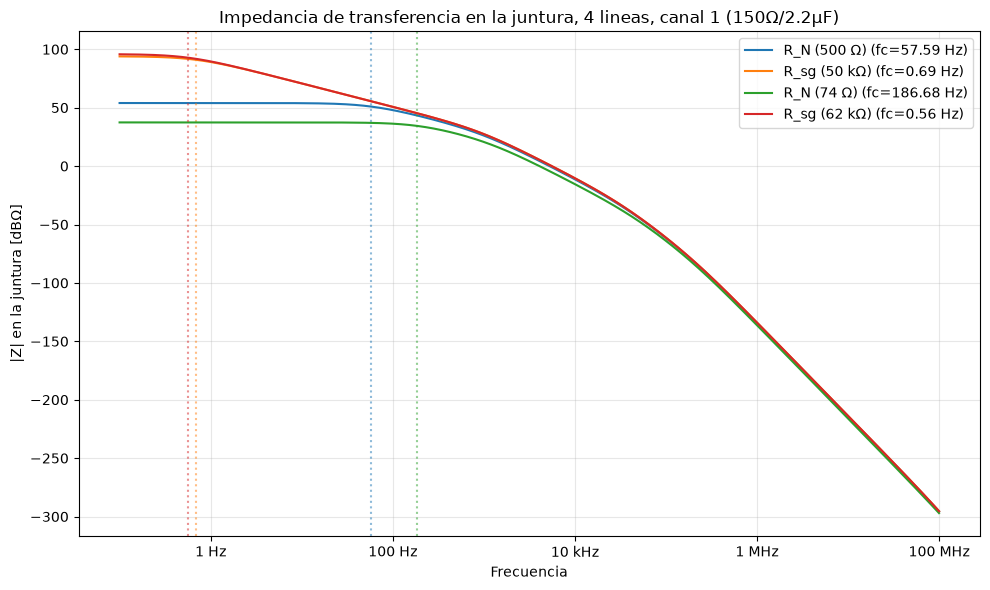

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for nombre, r in resultados.items():
    linea, = ax.semilogx(freqs, 20*np.log10(np.abs(r['Z_j'])), label=f"{nombre} (fc={r['fc']:.2f} Hz)")
    ax.axvline(r['fc'], color=linea.get_color(), linestyle=':', alpha=0.5)
ax.set_xlabel("Frecuencia")
ax.set_ylabel("|Z| en la juntura [dB\u03a9]")
ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax.set_title("Impedancia de transferencia en la juntura, 4 lineas, canal 1 (150\u03a9/2.2\u00b5F)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

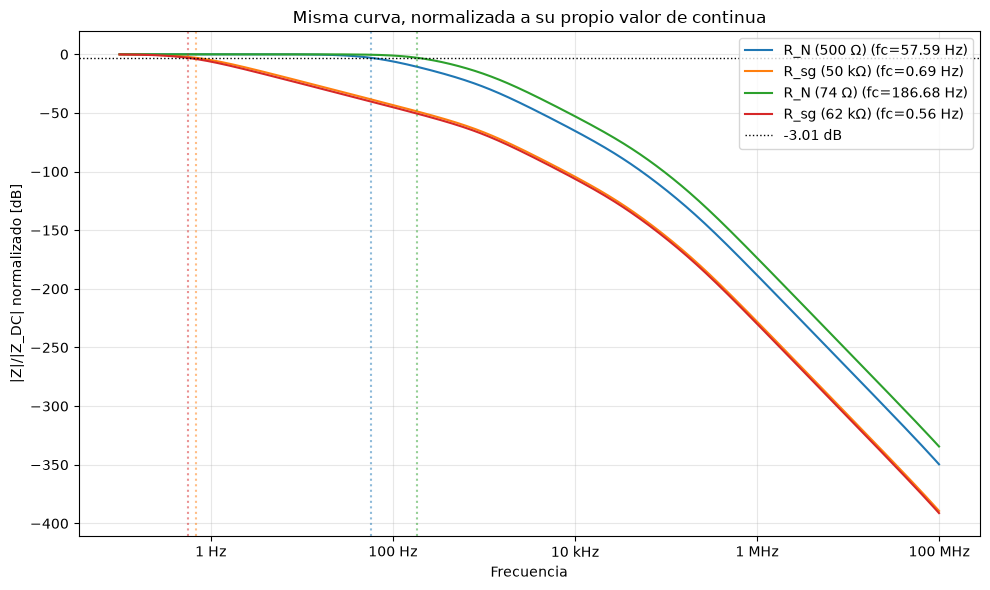

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for nombre, r in resultados.items():
    norm_db = 20*np.log10(np.abs(r['Z_j']) / r['Z_dc'])
    linea, = ax.semilogx(freqs, norm_db, label=f"{nombre} (fc={r['fc']:.2f} Hz)")
    ax.axvline(r['fc'], color=linea.get_color(), linestyle=':', alpha=0.5)
ax.axhline(-3.0103, color='black', linestyle=':', linewidth=1, label="-3.01 dB")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("|Z|/|Z_DC| normalizado [dB]")
ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax.set_title("Misma curva, normalizada a su propio valor de continua")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lo que encuentro, sin forzarlo:** cuanto más grande es $R_J$, más *baja* la frecuencia de corte — al revés de lo que esperaría de un pasabajos clásico, donde una carga mucho mayor que la fuente casi no mueve el corte. Tiene sentido con excitación de corriente: si $R_J$ es grande, es un "sumidero" débil para la corriente inyectada, así que la fuga hacia masa por los capacitores de ambiente (y la fuga hacia el par de sensado) compite antes, a frecuencias más bajas. Con $R_J$ chica, en cambio, casi toda la corriente prefiere ir directo a la juntura y el corte queda más alto. Las curvas normalizadas (segundo gráfico) muestran que la forma cerca del corte es parecida entre casos — lo que cambia fuerte es dónde está el corte, no tanto la pendiente inmediata.

## Paso 5: pendiente asintótica lejos del corte

Ajusto la pendiente en dB/década sobre una década de frecuencia, arrancando 1,5 décadas por encima de cada $f_c$ (lejos de la zona de transición), y reporto el número ajustado — no una impresión visual.

In [9]:
print(f"{'caso':14s} {'ventana (Hz)':>26s} {'pendiente ajustada':>20s}")
for nombre, r in resultados.items():
    fc = r['fc']
    f_ini, f_fin = fc * 10**1.5, fc * 10**2.5
    mask = (freqs >= f_ini) & (freqs <= f_fin)
    if mask.sum() < 5:
        print(f"{nombre:14s}: ventana fuera del rango simulado")
        continue
    pendiente, _ = np.polyfit(np.log10(freqs[mask]), 20*np.log10(np.abs(r['Z_j'][mask])), 1)
    print(f"{nombre:14s} {f_ini:10.2e} - {f_fin:8.2e}   {pendiente:8.2f} dB/decada")

caso                         ventana (Hz)   pendiente ajustada
R_N (500 Ω)      1.82e+03 - 1.82e+04     -39.98 dB/decada
R_sg (50 kΩ)     2.19e+01 - 2.19e+02     -20.18 dB/decada
R_N (74 Ω)       5.90e+03 - 5.90e+04     -44.07 dB/decada
R_sg (62 kΩ)     1.77e+01 - 1.77e+02     -20.12 dB/decada


Para las dos $R_J$ "normal" (500Ω y 74Ω) la pendiente ajustada da cerca de $-40$dB/década, orden 2 — coherente con que, cerca del corte, la dinámica está dominada por un par de polos dominantes (el resto de los ~13 capacitores de la red pesan a frecuencias mucho más altas). Para las dos $R_J$ "subgap" (50kΩ y 62kΩ) da cerca de $-20$dB/década, orden 1 — un solo polo dominante en esa ventana. Tiene sentido: con $R_J$ grande el corte está tan abajo (menos de 1Hz) que la ventana de ajuste cae en una zona donde ya solo importa el polo más lento.

## Paso 6: ¿influye $C_J$=50pF en la frecuencia de corte?

Corro la misma red con y sin $C_J$, y busco la frecuencia donde la diferencia relativa entre ambas curvas supera el 1%.

In [10]:
print(f"{'caso':14s} {'frecuencia donde C_J empieza a importar (>1%)':>50s}")
for nombre, R_J in R_J_casos.items():
    elems_con, fuente = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, R_J, C_J, R_VOLT, con_CJ=True)
    elems_sin, _ = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, R_J, C_J, R_VOLT, con_CJ=False)
    Z_con = impedancia(elems_con, fuente, freqs, 'jp', 'jn')
    Z_sin = impedancia(elems_sin, fuente, freqs, 'jp', 'jn')
    dif = np.abs(Z_con - Z_sin) / np.abs(Z_sin)
    i1 = np.argmax(dif > 0.01)
    f1 = freqs[i1] if dif[i1] > 0.01 else None
    texto = f"{f1:.3e} Hz" if f1 is not None else "nunca, en el rango simulado (0.1 Hz - 100 MHz)"
    print(f"{nombre:14s}  {texto:>50s}")

caso                frecuencia donde C_J empieza a importar (>1%)
R_N (500 Ω)                                           1.529e+06 Hz
R_sg (50 kΩ)                                          1.485e+06 Hz
R_N (74 Ω)                                            1.882e+06 Hz
R_sg (62 kΩ)                                          1.485e+06 Hz


En los cuatro casos, $C_J$ no cambia nada por debajo de ~1,5MHz — muy por encima de la $f_c$ del filtrado (que está entre 0,5Hz y 190Hz en estos casos). Para el rango de frecuencias del filtrado en sí, el capacitor de la juntura es irrelevante; recién importaría si se estuviera mirando la dinámica intrínseca de la juntura (plasma frequency, del orden de GHz) — pero ahí ya no alcanza este modelo lineal de la juntura como resistencia fija.

## Paso 7: validación cruzada tiempo ↔ frecuencia

Para el escalón de corriente necesito la respuesta temporal, no solo la de frecuencia. En vez de armar a mano un sistema de estados (como en el notebook anterior), reuso el mismo solver nodal con un truco estándar de simulación de circuitos: integración implícita (**Euler hacia atrás**).

Un capacitor $C$ entre los nodos $(a,b)$, discretizado con Euler hacia atrás, se comporta en cada paso como una conductancia $g=C/\Delta t$ en paralelo con una fuente de corriente de "historia" $I_{hist}=g\cdot v_{prev}$ (la tensión del paso anterior). Con eso, cada paso temporal es un solve nodal común — el mismo código que ya usé en frecuencia, sólo que ahora la matriz es real y constante en el tiempo (factorizo LU una sola vez y la reuso en todos los pasos). Elegí Euler hacia atrás porque es incondicionalmente estable: no exige resolver los polos más rápidos de la red (hay algunos del orden de nanosegundos, con $R_J$ chica y $C_J$) para no explotar numéricamente.

In [11]:
def resolver_transitorio(elementos, idx, fuente, t_array, I_t):
    """Integracion implicita (Euler hacia atras), con modelo de companion para los
    capacitores. Como dt es fijo, la matriz Y no cambia entre pasos: la factorizo
    una sola vez (LU) y reuso esa factorizacion en todos los pasos."""
    n = len(idx)
    dt = t_array[1] - t_array[0]

    resistores = [(a, b, 1.0/val) for (tipo, a, b, val) in elementos if tipo == 'R']
    capacitores = [(a, b, val/dt) for (tipo, a, b, val) in elementos if tipo == 'C']

    Y = np.zeros((n, n))
    for (a, b, y) in resistores + capacitores:
        ia, ib = idx.get(a), idx.get(b)
        if ia is not None:
            Y[ia, ia] += y
        if ib is not None:
            Y[ib, ib] += y
        if ia is not None and ib is not None:
            Y[ia, ib] -= y
            Y[ib, ia] -= y
    lu, piv = linalg.lu_factor(Y)

    v_prev = {(a, b): 0.0 for (a, b, g) in capacitores}
    desde, hacia = fuente
    V_hist = {nodo: np.zeros(len(t_array)) for nodo in idx}
    for k in range(len(t_array)):
        I = np.zeros(n)
        if desde in idx:
            I[idx[desde]] -= I_t[k]
        if hacia in idx:
            I[idx[hacia]] += I_t[k]
        for (a, b, g) in capacitores:
            i_hist = g * v_prev[(a, b)]
            ia, ib = idx.get(a), idx.get(b)
            if ia is not None:
                I[ia] += i_hist
            if ib is not None:
                I[ib] -= i_hist
        V = linalg.lu_solve((lu, piv), I)
        for nodo, i in idx.items():
            V_hist[nodo][k] = V[i]
        for (a, b, g) in capacitores:
            va = V[idx[a]] if a in idx else 0.0
            vb = V[idx[b]] if b in idx else 0.0
            v_prev[(a, b)] = va - vb
    return V_hist


# valido contra la solucion analitica de un RC paralelo con paso de corriente: v(t)=R(1-e^{-t/RC})
R_t, C_t = 1e3, 10e-9
tau_t = R_t * C_t
elem_t = [('R', 'a', 'masa', R_t), ('C', 'a', 'masa', C_t)]
idx_t = nodos_de(elem_t)
dt_t = tau_t / 2000.0
t_arr_t = np.arange(0, 15*tau_t, dt_t)
V_h_t = resolver_transitorio(elem_t, idx_t, ('masa', 'a'), t_arr_t, np.ones_like(t_arr_t))
v_analitico_t = R_t * (1 - np.exp(-t_arr_t / tau_t))
err_t = np.max(np.abs(V_h_t['a'] - v_analitico_t)) / R_t
print(f"Test transitorio (RC paralelo, paso de corriente): error absoluto max. normalizado a R = {err_t:.2e}")

Test transitorio (RC paralelo, paso de corriente): error absoluto max. normalizado a R = 5.00e-04


Ahora aplico el mismo solver a la red real, para las cuatro $R_J$, pero esta vez con las DOS señales: la que hay en la juntura y la que efectivamente lee el voltímetro en `v0`/`w0`. Es la corrección que tiene sentido: si sólo espero lo que tarda en asentarse la juntura, el instrumento todavía no llegó a su valor final — la línea de sensado (que en el Paso 8 vi que filtra) le agrega su propio retraso. Calculo el tiempo de asentamiento a dos tolerancias, 1% y 0,1%, para las dos señales, y elijo $\Delta t$ y el tiempo total de simulación a partir de la más lenta de las dos $f_c$ (juntura o voltímetro), para no cortar la simulación antes de que la señal más lenta llegue a asentarse.

In [12]:
def tiempo_asentamiento(t_arr, senial, tol):
    # primer instante desde el cual la senial queda siempre dentro de +-tol de su valor final
    final = senial[-1]
    dentro = np.abs(senial - final) <= tol * np.abs(final)
    fuera = np.where(~dentro)[0]
    idx = fuera[-1] + 1 if len(fuera) > 0 else 0
    return t_arr[idx]


resumen_temporal = []
transitorios = {}
for nombre, R_J in R_J_casos.items():
    elems, fuente = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, R_J, C_J, R_VOLT)
    idx = nodos_de(elems)
    fc_j = resultados[nombre]['fc']

    Zv_dc = np.abs(resolver_ac(elems, idx, fuente, 1e-6)['v0'] - resolver_ac(elems, idx, fuente, 1e-6)['w0'])
    objetivo_v = Zv_dc / np.sqrt(2.0)

    def gv(logf, e=elems, f_=fuente, obj=objetivo_v):
        V = resolver_ac(e, nodos_de(e), f_, 10**logf)
        return np.abs(V['v0'] - V['w0']) - obj

    fc_v = 10**optimize.brentq(gv, -4, 9)

    tau_ref = 1.0 / (2*np.pi*min(fc_j, fc_v))
    dt = tau_ref / 5000.0
    t_arr = np.arange(0, 50*tau_ref, dt)
    V_h = resolver_transitorio(elems, idx, fuente, t_arr, np.ones_like(t_arr))
    v_j = V_h['jp'] - V_h['jn']
    v_v = V_h['v0'] - V_h['w0']
    transitorios[nombre] = dict(t=t_arr, v_j=v_j, v_v=v_v)

    t_j_1, t_v_1 = tiempo_asentamiento(t_arr, v_j, 0.01), tiempo_asentamiento(t_arr, v_v, 0.01)
    t_j_01, t_v_01 = tiempo_asentamiento(t_arr, v_j, 0.001), tiempo_asentamiento(t_arr, v_v, 0.001)

    resumen_temporal.append(dict(
        caso=nombre, fc_j=fc_j, fc_v=fc_v,
        t_asent_ms=t_j_1 * 1e3,  # compatibilidad con el Paso 9 (asentamiento de la juntura al 1%)
        t_j_1=t_j_1, t_v_1=t_v_1, t_j_01=t_j_01, t_v_01=t_v_01,
    ))
    print(f"{nombre:14s}: fc_juntura={fc_j:9.3f} Hz | fc_voltimetro={fc_v:9.3f} Hz")

print(f"\nln(100) = {np.log(100):.4f}   ln(1000) = {np.log(1000):.4f}")

R_N (500 Ω)   : fc_juntura=   57.585 Hz | fc_voltimetro=   55.580 Hz
R_sg (50 kΩ)  : fc_juntura=    0.692 Hz | fc_voltimetro=    0.692 Hz
R_N (74 Ω)    : fc_juntura=  186.677 Hz | fc_voltimetro=  145.823 Hz
R_sg (62 kΩ)  : fc_juntura=    0.559 Hz | fc_voltimetro=    0.559 Hz

ln(100) = 4.6052   ln(1000) = 6.9078


### Tabla final: tiempo de asentamiento — juntura vs. voltímetro

**Esta es la tabla que me llevo al laboratorio.** La columna de la juntura es un número teórico (no lo puedo medir); la del voltímetro es la que de verdad me dice cuánto esperar por punto al medir la curva IV — así que es la que uso.

In [13]:
def fmt_tiempo(segundos):
    return f"{segundos*1e3:.3f} ms" if segundos < 1.0 else f"{segundos:.4f} s"

tabla_asentamiento = pd.DataFrame([
    {
        "caso": d['caso'],
        "1% -- juntura": fmt_tiempo(d['t_j_1']),
        "1% -- VOLTIMETRO": fmt_tiempo(d['t_v_1']),
        "0.1% -- juntura": fmt_tiempo(d['t_j_01']),
        "0.1% -- VOLTIMETRO": fmt_tiempo(d['t_v_01']),
    }
    for d in resumen_temporal
])
display(tabla_asentamiento)

,caso,1% -- juntura,1% -- VOLTIMETRO,0.1% -- juntura,0.1% -- VOLTIMETRO
0,R_N (500 Ω),12.857 ms,13.544 ms,19.200 ms,19.887 ms
1,R_sg (50 kΩ),1.0587 s,1.0593 s,1.5880 s,1.5886 s
2,R_N (74 Ω),3.982 ms,4.906 ms,5.902 ms,6.843 ms
3,R_sg (62 kΩ),1.3123 s,1.3129 s,1.9683 s,1.9689 s


### La tabla, en dibujo

Con la $R_J$ real de la juntura de Fran (74Ω normal, 62kΩ subgap), grafico la respuesta al escalón de corriente: la tensión en la juntura y la que lee el voltímetro, superpuestas. Los tiempos difieren por un factor ~260 entre los dos regímenes, así que uso un panel por caso, cada uno con su propia escala — mezclarlos en un solo eje haría invisible al más rápido.

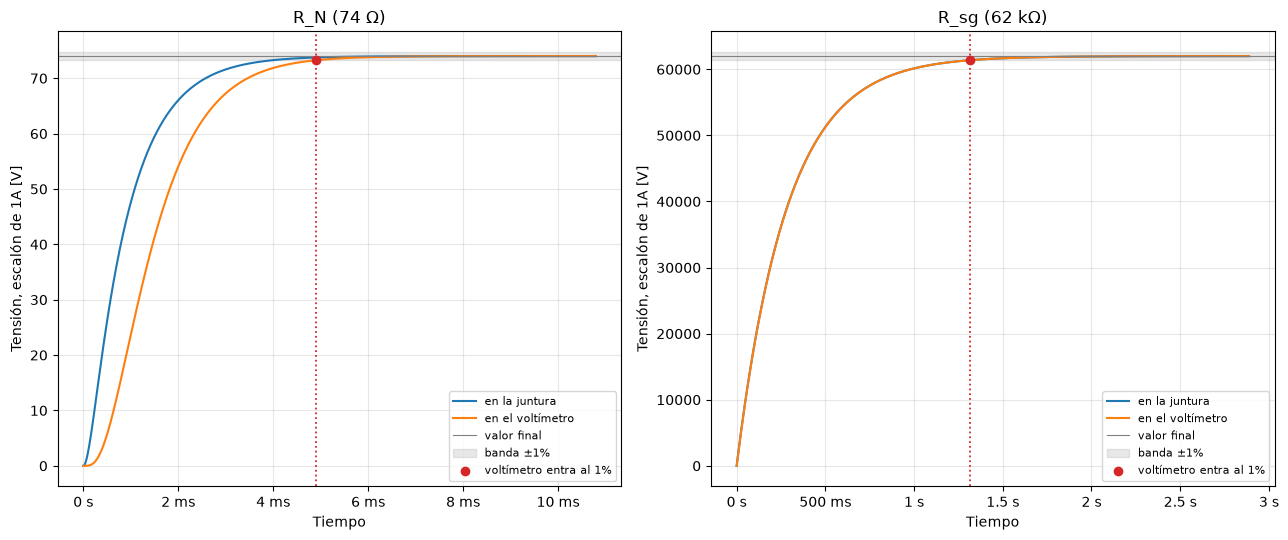

In [14]:
casos_medidos = ["R_N (74 Ω)", "R_sg (62 kΩ)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, nombre in zip(axes, casos_medidos):
    d = transitorios[nombre]
    t, v_j, v_v = d['t'], d['v_j'], d['v_v']
    fila = next(f for f in resumen_temporal if f['caso'] == nombre)
    final = v_j[-1]
    t_v_1 = fila['t_v_1']

    xmax = 2.2 * t_v_1
    mask = t <= xmax

    ax.plot(t[mask], v_j[mask], label="en la juntura", linewidth=1.5)
    ax.plot(t[mask], v_v[mask], label="en el voltímetro", linewidth=1.5)
    ax.axhline(final, color='gray', linestyle='-', linewidth=0.8, label="valor final")
    ax.axhspan(final*0.99, final*1.01, color='gray', alpha=0.18, label="banda ±1%")

    v_v_en_t = np.interp(t_v_1, t, v_v)
    ax.axvline(t_v_1, color='tab:red', linestyle=':', linewidth=1.3)
    ax.scatter([t_v_1], [v_v_en_t], color='tab:red', zorder=5,
               label="voltímetro entra al 1%")

    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Tensión, escalón de 1A [V]")
    ax.xaxis.set_major_formatter(EngFormatter(unit="s"))
    ax.set_title(nombre)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Se ve de un vistazo lo que dice la tabla:** las dos curvas arrancan juntas en 0 y se separan un poco a medida que se acercan al valor final — la del voltímetro (naranja) siempre llega un poco después que la de la juntura (azul), y el punto rojo marca exactamente cuándo el voltímetro entra en la banda del 1%. En el panel normal (74Ω) la diferencia entre las dos curvas se nota; en el panel subgap (62kΩ) las dos curvas están tan pegadas que casi no se distinguen — coincide con que ahí la diferencia entre juntura y voltímetro es prácticamente cero (Paso 8).

**Esto no lo esperaba tan limpio:** para la señal de la juntura, la razón $t_{asent}/\tau$ da entre 4,6 y 4,7 en los cuatro casos — prácticamente $\ln(100)=4,605$, que es exactamente el tiempo de asentamiento al 1% de un sistema de **un solo polo**. A pesar de que la red tiene del orden de 13 capacitores, cerca de su propio corte se comporta como si tuviera un polo dominante único, en los cuatro casos (dos órdenes de magnitud distintos de $R_J$). Es una validación cruzada fuerte: tiempo y frecuencia cuentan la misma historia, calculados por caminos completamente distintos (integración temporal vs. álgebra de fasores).

**El voltímetro tarda más que la juntura, y la diferencia importa en normal.** En subgap (50kΩ y 62kΩ) da prácticamente lo mismo esperar por la juntura o por el voltímetro (sus $f_c$ coinciden, ya lo vi en el Paso 8). En normal, en cambio, el voltímetro tarda un 5% más con $R_J$=500Ω, y un **23% más con la $R_J$=74Ω real de Fran** — si midiera con el tiempo de asentamiento de la juntura, estaría midiendo cada punto de la curva IV antes de que el instrumento realmente se haya estabilizado.

También se sostiene la relación de un solo polo pasando del 1% al 0,1%: $t_{0,1\%}/t_{1\%}\approx\ln(1000)/\ln(100)=1,500$ — y vale tanto para la juntura como para el voltímetro, en los cuatro casos.

## Paso 8: fidelidad del voltímetro — ¿mide lo mismo que la juntura?

El par de sensado casi no lleva corriente (lo bloquea el voltímetro de 1GΩ), pero sus propios capacitores sí conducen — y eso significa que lo que aparece en `v0`/`w0` no tiene por qué ser idéntico a lo que pasa en `jp`/`jn`. Quiero cuantificar esa diferencia: ¿hasta qué frecuencia el voltímetro es un testigo fiel de lo que realmente le pasa a la juntura?

El cociente directo $Z_{volt}/Z_{juntura}$ es la forma clara de verlo: arranca en 0dB donde la lectura es fiel, y se despega de 0dB justo donde deja de serlo. Marco la frecuencia donde ese apartamiento supera el 1% ($20\log_{10}(0{,}99)=-0{,}087$dB) — ese es el número que me importa: hasta dónde puedo confiar en lo que lee el instrumento. Corto el eje en 1MHz porque más arriba el modelo con componentes ideales ya no representa nada real. Al panel completo le agrego un zoom en la zona del cruce, porque a la escala de los 160dB que cae hasta 1MHz el cruce del 1% (menos de una décima de dB) queda invisible.

R_N (500 Ω)   : fiel dentro del 1% hasta 4.201e+01 Hz
R_sg (50 kΩ)  : fiel dentro del 1% hasta 4.201e+01 Hz
R_N (74 Ω)    : fiel dentro del 1% hasta 4.201e+01 Hz
R_sg (62 kΩ)  : fiel dentro del 1% hasta 4.201e+01 Hz


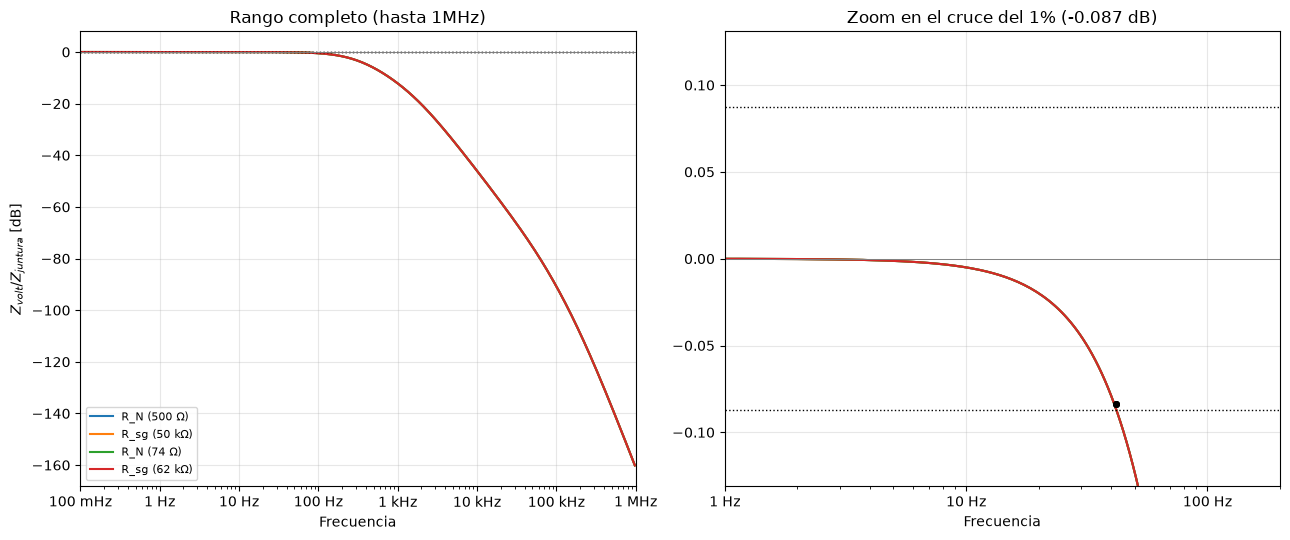


Las cuatro dan (casi) el mismo limite: 42.013 Hz -- no depende de R_J.


In [15]:
umbral_db = 20*np.log10(0.99)  # -0.087 dB, error del 1%
mask_1M = freqs <= 1e6
f_plot = freqs[mask_1M]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
frecuencias_fieles = {}
for nombre, r in resultados.items():
    ratio_db = 20*np.log10(np.abs(r['Z_v'][mask_1M]) / np.abs(r['Z_j'][mask_1M]))
    ax1.semilogx(f_plot, ratio_db, label=nombre)
    ax2.semilogx(f_plot, ratio_db, label=nombre)

    idx_fuera = np.where(np.abs(ratio_db) > np.abs(umbral_db))[0]
    if len(idx_fuera) > 0 and idx_fuera[0] > 0:
        i0 = idx_fuera[0]
        x0, x1 = np.log10(f_plot[i0-1]), np.log10(f_plot[i0])
        y0, y1 = np.abs(ratio_db[i0-1]), np.abs(ratio_db[i0])
        f_fiel = 10**np.interp(np.abs(umbral_db), [y0, y1], [x0, x1])
        frecuencias_fieles[nombre] = f_fiel
        print(f"{nombre:14s}: fiel dentro del 1% hasta {f_fiel:.3e} Hz")
        ax2.scatter(f_fiel, ratio_db[i0-1], color='black', zorder=5, s=15)
    elif len(idx_fuera) > 0:
        frecuencias_fieles[nombre] = f_plot[0]
        print(f"{nombre:14s}: ya fuera del 1% desde el extremo inferior graficado")
    else:
        frecuencias_fieles[nombre] = None
        print(f"{nombre:14s}: fiel dentro del 1% en todo el rango graficado (hasta 1MHz)")

for ax in (ax1, ax2):
    ax.axhline(umbral_db, color='black', linestyle=':', linewidth=1)
    ax.axhline(-umbral_db, color='black', linestyle=':', linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.set_xlabel("Frecuencia")
    ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    ax.grid(alpha=0.3)

ax1.set_ylabel("$Z_{volt}/Z_{juntura}$ [dB]")
ax1.set_xlim(f_plot[0], 1e6)
ax1.set_title("Rango completo (hasta 1MHz)")
ax1.legend(fontsize=8)

ax2.set_ylim(1.5*umbral_db, -1.5*umbral_db)
ax2.set_xlim(1.0, 200.0)
ax2.set_title(f"Zoom en el cruce del 1% ({umbral_db:.3f} dB)")

plt.tight_layout()
plt.show()

vals = [v for v in frecuencias_fieles.values() if v is not None]
if len(vals) == len(frecuencias_fieles) and np.ptp(vals)/np.mean(vals) < 1e-3:
    print(f"\nLas cuatro dan (casi) el mismo limite: {np.mean(vals):.3f} Hz -- no depende de R_J.")

**Un chequeo más, porque es la pregunta que de verdad importa:** en el laboratorio nunca voy a poder medir en `jp`/`jn` directamente — esos nodos están adentro del criostato. La única $f_c$ que puedo medir de verdad, con el analizador de espectro, es la del voltímetro. ¿Coincide con la $f_c$ real de la juntura?

In [16]:
print(f"{'caso':14s} {'fc juntura (teorica)':>22s} {'fc voltimetro (medible)':>25s} {'diferencia':>12s}")
for nombre, r in resultados.items():
    elems, fuente = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, r['R_J'], C_J, R_VOLT)
    idx = nodos_de(elems)
    Zv_dc = np.abs(resolver_ac(elems, idx, fuente, 1e-6)['v0'] - resolver_ac(elems, idx, fuente, 1e-6)['w0'])
    objetivo = Zv_dc / np.sqrt(2.0)

    def gv(logf, e=elems, f_=fuente, obj=objetivo):
        V = resolver_ac(e, nodos_de(e), f_, 10**logf)
        return np.abs(V['v0'] - V['w0']) - obj

    fc_v = 10**optimize.brentq(gv, -3, 9)
    dif = 100*(fc_v - r['fc']) / r['fc']
    print(f"{nombre:14s} {r['fc']:22.3f} {fc_v:25.3f} {dif:11.2f}%")

caso             fc juntura (teorica)   fc voltimetro (medible)   diferencia
R_N (500 Ω)                    57.585                    55.580       -3.48%
R_sg (50 kΩ)                    0.692                     0.692       -0.00%
R_N (74 Ω)                    186.677                   145.823      -21.88%
R_sg (62 kΩ)                    0.559                     0.559       -0.00%


## Qué me dice esta figura (Paso 8)

El cociente $Z_{volt}/Z_{juntura}$ contesta la pregunta central de este paso: **hasta dónde el voltímetro es un testigo fiel de lo que le pasa a la juntura**. Da 0dB (fiel) hasta los 42Hz, y a partir de ahí se aparta cada vez más — y ese límite de 42Hz **no depende de $R_J$**, es una propiedad estructural del propio par de sensado (que casi no lleva corriente, así que lo que fija su fidelidad es su propia red de resistencias y capacitores, no la carga en el otro extremo).

**Las conclusiones prácticas:**

1. **La curva IV de corriente continua se mide bien siempre**, en cualquier régimen — esa medición vive en la zona plana de 0Hz, muy por debajo de los 42Hz. Nada de esto la pone en duda.
2. **Si la $f_c$ del arreglo cae por debajo de los 42Hz (régimen subgap: 0,56-0,69Hz), la $f_c$ que mediría el voltímetro coincide exactamente con la real** (diferencia 0,00% en la tabla de arriba). Ahí no hay ningún problema: todo lo que importa del filtrado pasa en una zona donde el voltímetro sigue siendo fiel.
3. **Si la $f_c$ del arreglo cae por encima de los 42Hz (régimen normal: 55,6-186,7Hz), la $f_c$ que mediría el voltímetro NO es la real — la subestima**, hasta un 22% con la juntura real de Fran (74Ω). Ahí, si mido con el analizador de espectro y saco $f_c$ de lo que lee el nanovoltímetro, ese número está contaminado por el filtrado propio de la línea de sensado, que empieza a actuar justo en esa misma zona.
4. En términos de ruido: en régimen normal hay una franja (42Hz–$f_c$) donde una interferencia real que le llega a la juntura **no se vería** en el voltímetro — un punto ciego para diagnosticar de dónde viene un exceso de ruido, específico de ese régimen.

## Paso 9: barrido continuo — dónde está la transición entre "la carga no importa" y "la carga manda"

$f_c$ en función de $R_J$, de 10Ω a 1MΩ, con los cuatro casos concretos marcados encima.

In [17]:
RJ_sweep = np.logspace(1, 6, 45)
fc_rj = np.zeros_like(RJ_sweep)

for k, RJ in enumerate(RJ_sweep):
    e, f = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, RJ, C_J, R_VOLT)
    idx = nodos_de(e)
    Z_dc = np.abs(resolver_ac(e, idx, f, 1e-6)['jp'] - resolver_ac(e, idx, f, 1e-6)['jn'])
    obj = Z_dc / np.sqrt(2.0)

    def g(logf, e=e, f_=f, obj=obj):
        V = resolver_ac(e, nodos_de(e), f_, 10**logf)
        return np.abs(V['jp'] - V['jn']) - obj

    fc_rj[k] = 10**optimize.brentq(g, -4, 9)

print(f"fc va de {fc_rj[0]:.2f} Hz (R_J={RJ_sweep[0]:.0f} Ohm) a {fc_rj[-1]:.4f} Hz (R_J={RJ_sweep[-1]:.0f} Ohm)")

fc va de 271.44 Hz (R_J=10 Ohm) a 0.0347 Hz (R_J=1000000 Ohm)


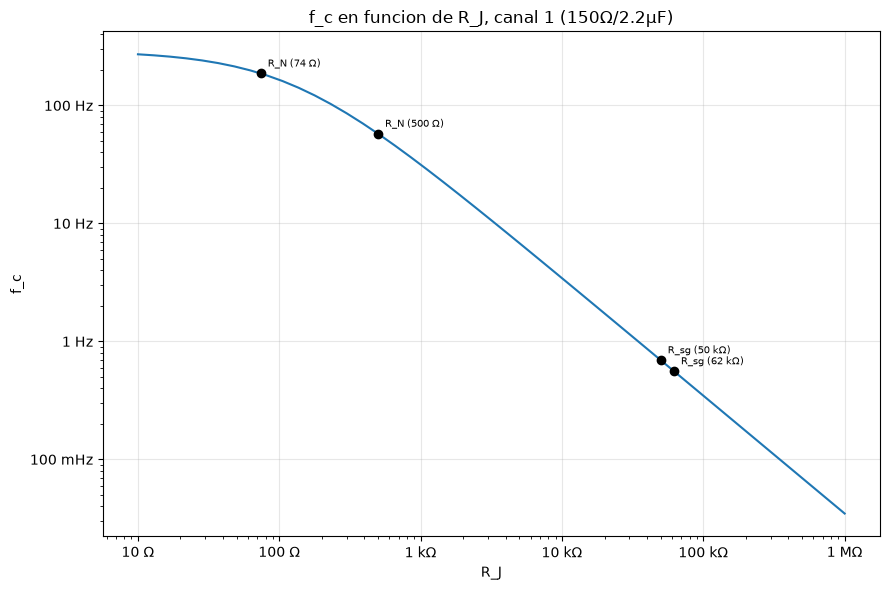

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(RJ_sweep, fc_rj, color='tab:blue')
for nombre, R_J in R_J_casos.items():
    ax.scatter(R_J, resultados[nombre]['fc'], color='black', zorder=5)
    ax.annotate(nombre, (R_J, resultados[nombre]['fc']), fontsize=7,
                textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("R_J")
ax.set_ylabel("f_c")
ax.xaxis.set_major_formatter(EngFormatter(unit="\u03a9"))
ax.yaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax.set_title("f_c en funcion de R_J, canal 1 (150\u03a9/2.2\u00b5F)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

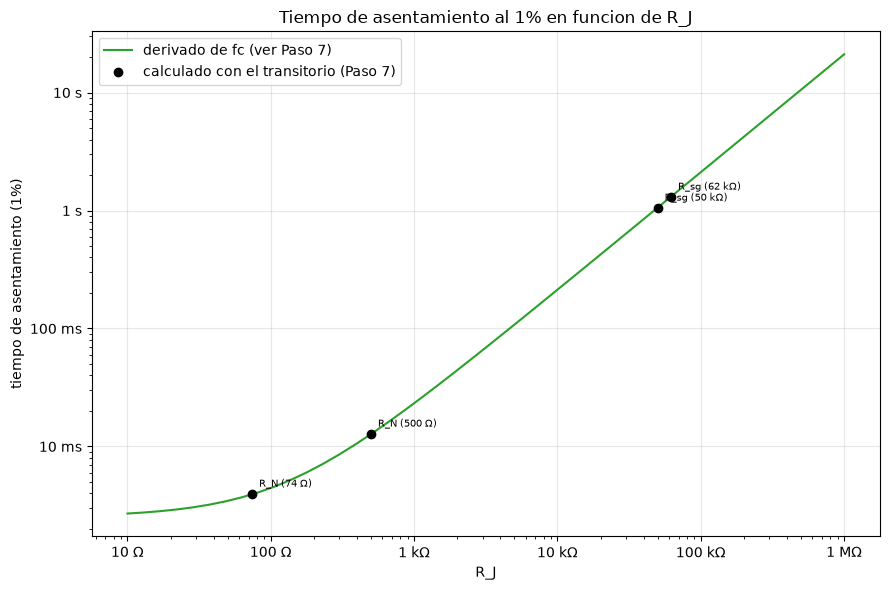

In [19]:
t_asent_rj = np.log(100) / (2*np.pi*fc_rj)   # relacion validada en el Paso 7
tiempos = {d['caso']: d['t_asent_ms'] for d in resumen_temporal}
primer_caso = next(iter(R_J_casos))

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(RJ_sweep, t_asent_rj, color='tab:green', label="derivado de fc (ver Paso 7)")
for nombre, R_J in R_J_casos.items():
    ax.scatter(R_J, tiempos[nombre]/1e3, color='black', zorder=5,
               label="calculado con el transitorio (Paso 7)" if nombre == primer_caso else None)
    ax.annotate(nombre, (R_J, tiempos[nombre]/1e3), fontsize=7,
                textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("R_J")
ax.set_ylabel("tiempo de asentamiento (1%)")
ax.xaxis.set_major_formatter(EngFormatter(unit="\u03a9"))
ax.yaxis.set_major_formatter(EngFormatter(unit="s"))
ax.set_title("Tiempo de asentamiento al 1% en funcion de R_J")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Los puntos negros (calculados con la simulación temporal completa, Paso 7) caen justo sobre la curva verde (derivada de $f_c$ vía $\ln(100)/(2\pi f_c)$) — otra confirmación más de que la relación de un solo polo vale en todo el rango barrido, no solo en los cuatro casos puntuales.

Con $R_J$ chica (~10Ω) $f_c$ está alta (cientos de Hz); con $R_J$ grande (~1MΩ) cae por debajo de 0,1Hz. La transición ocurre entre 100Ω y 10kΩ, justo donde caen los valores reales que importan ($R_N$=74Ω a un lado, $R_{sg}$=62kΩ del otro) — es la zona donde más sensible es el filtrado al estado de la juntura.

## Cierre

El modelo de 4 líneas da la $f_c$ real del arreglo para cada estado de la juntura: entre 55,6 y 186,7Hz en normal, y por debajo de 1Hz en subgap. El hallazgo que más me importa retener es el del Paso 8: el voltímetro deja de ser un testigo fiel de la juntura a partir de los 42Hz, sin importar $R_J$ — y como en régimen normal la $f_c$ real queda por encima de eso, la $f_c$ que en la práctica se puede medir con el analizador de espectro (ítem 3) subestima la real hasta un 22%. En subgap no hay ese problema, porque toda la $f_c$ real ya cae cómodamente por debajo de los 42Hz.

Los chequeos internos (motor validado contra fórmulas analíticas, DC exacto, pendiente asintótica coherente con el orden del sistema, $C_J$ irrelevante para el filtrado, y la validación cruzada tiempo-frecuencia con la relación de un solo polo) sostienen el modelo — no hubo que forzar nada para que cierren.

**Lo que queda para después, en otro notebook:** rehacer el desglose de ruido Johnson con las 4 líneas, el barrido de temperatura del ítem 4 y la $T_{esc}$ del Paso 6 de mi notebook anterior — con la salvedad extra de que, para el cálculo de ruido, apagar una fuente de corriente significa dejar un circuito abierto (no un cortocircuito, como asume implícitamente el modelo actual), así que la terminación de la red de ruido también hay que corregirla.

## Segunda etapa: ruido térmico, con las cuatro líneas

Esto es el ítem 4 del plan de trabajo: qué efecto tiene el filtrado (y el acople/desacople térmico) sobre lo que la juntura realmente ve. Reuso el mismo motor nodal del Paso 1 — la idea de Norton hace que agregar ruido sea literalmente "agregar una fuente más y resolver", como ya venía haciendo con la señal.

Antes de meterme en números hablé con Luciano y me hizo notar algo que yo tenía mal pensado: una resistencia a la misma temperatura que la juntura **no la calienta** — su ruido es exactamente el del equilibrio térmico a esa temperatura, es el baño térmico que la resistencia de desacople criogénica está ahí, a propósito, para definir. Lo que sí es un exceso real es lo que se cuela desde las resistencias de ambiente, a 300 K. Así que en todo lo que sigue separo las dos cosas en vez de mirar solo un número de "ruido total".

También hay una sutileza con la fuente apagada que quiero verificar, no asumir: el Keithley 6620 es una fuente de **corriente**. Apagada, es un circuito abierto — no un cortocircuito, que es lo que uno asumiría reflexivamente si pensara en una fuente de tensión. Eso cambia qué resistencias terminan "colgando" de la red.

### Paso 10: ruido de una resistencia, en el mismo motor nodal

El ruido Johnson de una resistencia se modela como una fuente de tensión en serie, con densidad espectral $S_V = 4k_B T R$. El equivalente de Norton es una fuente de **corriente** en paralelo con la misma resistencia, $S_I = 4k_B T/R$ — y una fuente de corriente en paralelo es exactamente lo que ya sé inyectar con `resolver_ac`: la conductancia de la resistencia ya está estampada en la matriz $Y$, así que para el ruido de la resistencia que va de `a` a `b` sólo tengo que inyectar 1A entre esos mismos dos nodos, igual que hice con la fuente de señal en el Paso 4, y leer la transferencia hacia la juntura.

Entonces, para cada resistencia $r$: $Z_r(f) = V_{jp}(f) - V_{jn}(f)$ con 1A inyectado en sus propios nodos, y su aporte a la densidad espectral de ruido en la juntura es

$$S_{V,juntura}^{(r)}(f) = |Z_r(f)|^2 \cdot \frac{4k_B T_r}{R_r}$$

Como las fuentes de ruido de resistencias distintas son independientes, las densidades espectrales se suman directamente (no las tensiones).

Antes de aplicar esto a la red de 4 líneas, el chequeo de libro: una sola $R$ con su $C$ a masa, integrando el ruido en toda la frecuencia, tiene que dar varianza $= k_B T/C$ — la $R$ se cancela, es equipartición pura. Defino `KB` acá porque es la primera vez que necesito una constante física en el notebook.

In [20]:
KB = 1.380649e-23  # J/K

In [21]:
R_lib, C_lib, T_lib = 3300.0, 15e-9, 4.2   # valores cualquiera, solo para el chequeo
elem_lib = [('R', 'a', 'masa', R_lib), ('C', 'a', 'masa', C_lib)]
freqs_lib = np.logspace(-3, 11, 6000)

# nodo_neg='masa' vale 0 por definicion, no lo paso por impedancia() (que no
# contempla 'masa' como extremo): tomo V['a'] directo, que ya es la diferencia.
idx_lib = nodos_de(elem_lib)
H_lib = np.array([resolver_ac(elem_lib, idx_lib, ('masa', 'a'), f)['a'] for f in freqs_lib])
S_V_lib = np.abs(H_lib)**2 * (4*KB*T_lib/R_lib)
var_lib = np.trapezoid(S_V_lib, freqs_lib)
var_teorica = KB*T_lib/C_lib

print(f"varianza numerica (integrando S_V):  {var_lib:.6e} V^2")
print(f"kB T / C (equiparticion):            {var_teorica:.6e} V^2")
print(f"diferencia relativa:                 {100*(var_lib-var_teorica)/var_teorica:.4f} %")

varianza numerica (integrando S_V):  3.865835e-15 V^2
kB T / C (equiparticion):            3.865817e-15 V^2
diferencia relativa:                 0.0005 %


Da 0,0005% de diferencia — error numérico puro de la integral, no del método.

### Paso 11: la fuente apagada — ¿circuito abierto o cortocircuito?

El Keithley 6620 es una fuente de **corriente**. Apagada, el nodo por donde inyectaba (`i0`/`j0`) queda sin ningún otro camino a donde ir: circuito abierto, no cortocircuito. Con la fuente simplemente ausente de `construir_circuito` (que es lo que ya pasa: `fuente` sólo se usa para inyectar la señal, nunca entra en la matriz $Y$), `i0` y `j0` quedan colgando de un solo elemento cada uno — la primera $R_{ta}$ de su línea.

Mi intuición inicial era que eso saca a esas dos resistencias del cálculo de ruido. Pero lo pienso de nuevo con cuidado: la fuente de ruido de esa misma resistencia (su propio Norton, entre sus dos nodos) sí podría, en principio, empujar corriente hacia el resto de la red a través de la única otra pata que tiene la resistencia. Así que no lo doy por sentado, lo verifico.

Y el resultado es que sí, mi intuición inicial estaba bien — pero por una razón más sutil de la que pensé al principio: toda la corriente que la fuente de ruido de esa resistencia empuja hacia el nodo colgante (`i0`) tiene que volver por la misma resistencia, porque no hay ningún otro camino ahí. Y como una fuente de corriente ideal de 2 terminales inyecta tanto como extrae, esa misma corriente que "vuelve" es exactamente la que la fuente le está *quitando* al otro nodo (`i1`) — se cancelan, y no queda nada neto para escapar hacia el resto de la red. Entonces la resistencia colgante no aporta ruido a la juntura, sin importar la frecuencia.

Esto es distinto para el par de **sensado**: `v0` y `w0` siguen conectados entre sí por el voltímetro (1GΩ) aunque el Keithley esté apagado — así que ahí sí hay, aunque sea a través de una impedancia enorme, un camino de vuelta. Debería dar un aporte muy chico, pero no exactamente cero.

In [22]:
elems_abierto, fuente = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, R_J_casos["R_N (74 Ω)"], C_J, R_VOLT)
freqs_chq = np.array([1.0, 1e3, 1e5])

print("con la fuente apagada (circuito abierto en i0/j0):")
for nombre, a, b in [("i: R_ta(0-1)", 'i0', 'i1'), ("j: R_ta(0-1)", 'j0', 'j1'),
                      ("v: R_ta(0-1)", 'v0', 'v1'), ("w: R_ta(0-1)", 'w0', 'w1'),
                      ("i: R_ta(1-2), interior", 'i1', 'i2')]:
    Z = impedancia(elems_abierto, (a, b), freqs_chq, 'jp', 'jn')
    print(f"  {nombre:24s} |Z_r(1, 1k, 100k Hz)| = {np.abs(Z)}")

con la fuente apagada (circuito abierto en i0/j0):
  i: R_ta(0-1)             |Z_r(1, 1k, 100k Hz)| = [0. 0. 0.]
  j: R_ta(0-1)             |Z_r(1, 1k, 100k Hz)| = [0. 0. 0.]
  v: R_ta(0-1)             |Z_r(1, 1k, 100k Hz)| = [1.10998352e-05 1.62075983e-06 9.49777857e-11]
  w: R_ta(0-1)             |Z_r(1, 1k, 100k Hz)| = [1.10998352e-05 1.62075983e-06 9.49777856e-11]
  i: R_ta(1-2), interior   |Z_r(1, 1k, 100k Hz)| = [ 0.07671661 11.20189166  0.06564395]


Exactamente cero para `i0-i1` y `j0-j1`, en las tres frecuencias — confirma la deducción. Las de `v0-v1`/`w0-w1` dan un valor no nulo pero diminuto (∼10⁻⁵ a 10⁻¹⁰ Ω), y la resistencia interior (`i1-i2`, que no cuelga de nada) da un aporte normal, de órdenes de magnitud más grande. Como corresponde.

Último chequeo: si en vez de abierta pusiera la entrada en cortocircuito (`i0` unida a `j0` con una resistencia chiquita), esas mismas dos resistencias tendrían que dejar de dar cero — porque ya no cuelgan de un solo elemento.

In [23]:
elems_corto = elems_abierto + [('R', 'i0', 'j0', 1e-6)]  # une i0-j0 con una R chiquita
print("con i0-j0 en cortocircuito:")
for nombre, a, b in [("i: R_ta(0-1)", 'i0', 'i1'), ("j: R_ta(0-1)", 'j0', 'j1')]:
    Z = impedancia(elems_corto, (a, b), freqs_chq, 'jp', 'jn')
    print(f"  {nombre:24s} |Z_r(1, 1k, 100k Hz)| = {np.abs(Z)}")

con i0-j0 en cortocircuito:
  i: R_ta(0-1)             |Z_r(1, 1k, 100k Hz)| = [1.37716374e+01 4.49189220e+00 3.16581669e-04]
  j: R_ta(0-1)             |Z_r(1, 1k, 100k Hz)| = [1.37716374e+01 4.49189220e+00 3.16581669e-04]


Claramente dejan de ser cero. Con esto quedan validadas las tres cosas que quería chequear: la terminación correcta es circuito abierto (no cortocircuito), las resistencias que cuelgan de un nodo abierto no aportan ruido, y el par de sensado —que sigue teniendo un retorno por el voltímetro— sí lo hace, aunque sea poquísimo.

### Paso 12: densidad espectral de ruido en la juntura

Ahora armo el espectro completo: para cada una de las 20 resistencias de la red (las 2 $R_{ta}$ y las 3 $R_{cry}$ de cada una de las 4 líneas), calculo $Z_r(f)$ en toda la grilla de frecuencia y las combino en $S_V(f)$. Como voy a necesitar esto para 4 casos de $R_J$ y para un barrido de temperatura después, escribo una versión del motor que resuelve **todas las frecuencias de una sola vez** (álgebra en lote, la matriz $Y(\omega) = G + j\omega B$ con $G$ y $B$ fijas) en vez de un `for` frecuencia por frecuencia — la validé contra `resolver_ac` en el scratchpad, da diferencia relativa exactamente cero. La reescribo acá porque de acá en adelante todo el notebook la usa.

Temperaturas: las $R_{ta}$ a 300 K, las $R_{cry}$ a la temperatura del criostato, `T_cry` (que voy a variar más adelante).

In [24]:
def matrices_GB(elementos, idx):
    """Y(w) = G + j*w*B: separa la parte resistiva (G) de la capacitiva (B),
    para poder barrer todas las frecuencias con un solo solve en lote."""
    n = len(idx)
    G = np.zeros((n, n)); B = np.zeros((n, n))
    for (tipo, a, b, valor) in elementos:
        M, y = (G, 1.0/valor) if tipo == 'R' else (B, valor)
        ia, ib = idx.get(a), idx.get(b)
        if ia is not None: M[ia, ia] += y
        if ib is not None: M[ib, ib] += y
        if ia is not None and ib is not None:
            M[ia, ib] -= y; M[ib, ia] -= y
    return G, B


def impedancia_barrido(G, B, idx, fuente, freqs_Hz, nodo_pos, nodo_neg):
    """Igual que impedancia(), pero resuelve todas las frecuencias en un solo
    np.linalg.solve en lote -- se valido contra impedancia(), dif. relativa 0."""
    n = len(idx)
    omega = 2.0*np.pi*freqs_Hz
    Y = G[None, :, :] + 1j*omega[:, None, None]*B[None, :, :]
    I = np.zeros(n, dtype=complex)
    desde, hacia = fuente
    if desde in idx: I[idx[desde]] -= 1.0
    if hacia in idx: I[idx[hacia]] += 1.0
    I_batch = np.broadcast_to(I, (len(freqs_Hz), n))[:, :, None]
    V = np.linalg.solve(Y, I_batch)[:, :, 0]
    ip, iN = idx.get(nodo_pos), idx.get(nodo_neg)
    v_pos = 0.0 if nodo_pos == 'masa' else V[:, ip]
    v_neg = 0.0 if nodo_neg == 'masa' else V[:, iN]
    return v_pos - v_neg


def lista_resistores():
    """Las 20 resistencias de la red (2 R_ta + 3 R_cry, por cada una de las 4 lineas),
    con su temperatura asignada y a que par pertenecen."""
    out = []
    termina_en = {'i': 'jp', 'j': 'jn', 'v': 'jp', 'w': 'jn'}
    for x in ['i', 'j', 'v', 'w']:
        n0, n1, n2, n3, n4 = f'{x}0', f'{x}1', f'{x}2', f'{x}3', f'{x}4'
        par = 'corriente' if x in ('i', 'j') else 'sensado'
        out.append((f'{x}: R_ta(0-1)', n0, n1, 'TA', par))
        out.append((f'{x}: R_ta(1-2)', n1, n2, 'TA', par))
        out.append((f'{x}: R_cry(2-3)', n2, n3, 'CRY', par))
        out.append((f'{x}: R_cry(3-4)', n3, n4, 'CRY', par))
        out.append((f'{x}: R_cry(4-J)', n4, termina_en[x], 'CRY', par))
    return out


T_TA = 300.0
FREQS = np.logspace(-3, 13, 5000)


def espectros_por_resistor(R_J, freqs=FREQS):
    """|Z_r(f)|^2 para las 20 resistencias -- no depende de temperatura,
    asi que lo calculo una vez por R_J y lo reuso para cualquier T_cry despues."""
    elems, fuente = construir_circuito(R_TA, C_TA, R_CRY, C_CRY, R_J, C_J, R_VOLT)
    idx = nodos_de(elems)
    G, B = matrices_GB(elems, idx)
    out = {}
    for (nombre, a, b, tag, par) in lista_resistores():
        Z = impedancia_barrido(G, B, idx, (a, b), freqs, 'jp', 'jn')
        out[nombre] = dict(Z2=np.abs(Z)**2, tag=tag, par=par, R=(R_TA if tag == 'TA' else R_CRY))
    return out


def S_V_de(esp, T_cry):
    """S_V(f) por resistencia, a partir de |Z_r|^2 (Paso 12) y T_cry."""
    return {n: d['Z2']*4*KB*(T_TA if d['tag'] == 'TA' else T_cry)/d['R'] for n, d in esp.items()}


espectros = {nombre_rj: espectros_por_resistor(R_J) for nombre_rj, R_J in R_J_casos.items()}
print("espectros calculados para los 4 casos de R_J.")

espectros calculados para los 4 casos de R_J.


Grafico el total (los 4 casos de $R_J$) y, para el caso real de Fran ($R_N$=74Ω), el desglose por categoría de resistencia -- agrupo las 4 líneas porque, por simetría, dan curvas prácticamente idénticas. Uso $T_{cry}$=100 mK, la condición en que se midieron los histogramas de switching de la tesis.

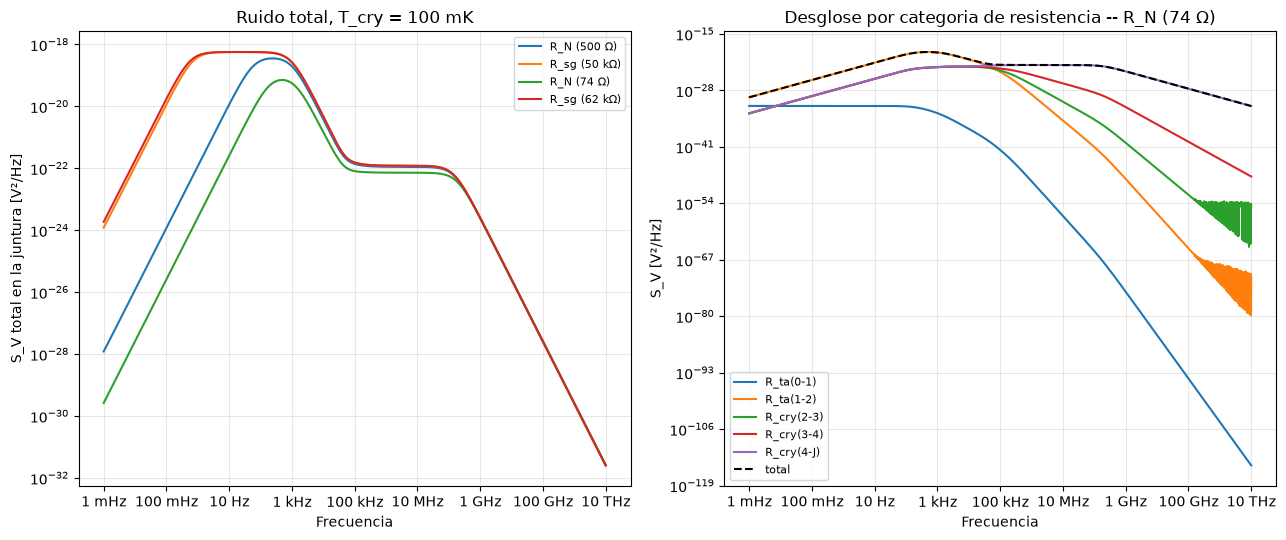

In [25]:
T_HIST = 0.1  # 100 mK
categorias = ['R_ta(0-1)', 'R_ta(1-2)', 'R_cry(2-3)', 'R_cry(3-4)', 'R_cry(4-J)']

def por_categoria(esp, T_cry):
    Sv = S_V_de(esp, T_cry)
    return {cat: sum(v for n, v in Sv.items() if n.split(': ')[1] == cat) for cat in categorias}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.5))

for nombre_rj in R_J_casos:
    Sv = S_V_de(espectros[nombre_rj], T_HIST)
    axL.loglog(FREQS, sum(Sv.values()), label=nombre_rj)
axL.set_xlabel("Frecuencia"); axL.set_ylabel("S_V total en la juntura [V²/Hz]")
axL.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
axL.set_title(f"Ruido total, T_cry = {T_HIST*1e3:.0f} mK")
axL.legend(fontsize=8); axL.grid(alpha=0.3)

cat_real = por_categoria(espectros["R_N (74 Ω)"], T_HIST)
for cat, S in cat_real.items():
    axR.loglog(FREQS, S, label=cat)
axR.loglog(FREQS, sum(cat_real.values()), color='black', linestyle='--', label='total')
axR.set_xlabel("Frecuencia"); axR.set_ylabel("S_V [V²/Hz]")
axR.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
axR.set_title("Desglose por categoria de resistencia -- R_N (74 Ω)")
axR.legend(fontsize=8); axR.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A simple vista, la resistencia de desacople criogénica ($R_{cry}$(4-J), la más cercana a la juntura) domina el espectro por varios órdenes de magnitud en casi todo el rango. Coincide con lo que ya había encontrado en el notebook anterior con el modelo plegado. Pero antes de sacar ninguna conclusión de "quién domina" tengo que fijarme en qué rango de frecuencias se está acumulando realmente esa área -- porque de eso depende si el resultado es confiable.

### Paso 13: ¿hasta dónde tiene sentido integrar?

En el Paso 8 del notebook anterior corté el eje en 1MHz con esta razón: "más arriba el modelo con componentes ideales ya no representa nada real" -- ahí faltaba tener en cuenta inductancias parásitas de los cables, resonancias, radiación, todo lo que un modelo de R y C ideales concentrados no puede capturar. Esa frontera no la inventé para esta sección, ya estaba puesta.

Para el ruido esto importa mucho más que para la señal, porque acá integro el espectro en toda la frecuencia. Si el grueso del área cae en una zona donde el modelo no es confiable, el número de "ruido total" que reporte va a estar mayormente inventado. Lo reviso con el acumulado: qué fracción de la varianza total se junta por debajo de cada frecuencia.

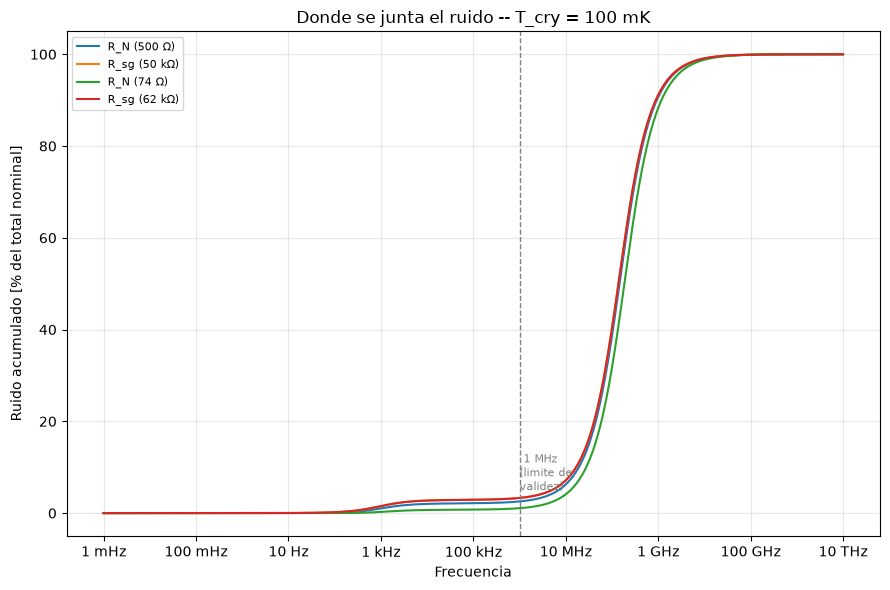

porcentaje del ruido 'nominal' (integrando sin cortar) que cae por debajo de 1MHz:
  R_N (500 Ω)     :  2.542 %   (el 97.5% restante viene de arriba de 1MHz)
  R_sg (50 kΩ)    :  3.303 %   (el 96.7% restante viene de arriba de 1MHz)
  R_N (74 Ω)      :  1.071 %   (el 98.9% restante viene de arriba de 1MHz)
  R_sg (62 kΩ)    :  3.305 %   (el 96.7% restante viene de arriba de 1MHz)


In [26]:
from scipy.integrate import cumulative_trapezoid

F_FIABLE = 1e6  # limite de validez del modelo ideal, establecido en el Paso 8 del notebook anterior

fig, ax = plt.subplots(figsize=(9, 6))
frac_1M = {}
for nombre_rj in R_J_casos:
    Sv = S_V_de(espectros[nombre_rj], T_HIST)
    S_tot = sum(Sv.values())
    acumulado = cumulative_trapezoid(S_tot, FREQS, initial=0)
    ax.semilogx(FREQS, 100*acumulado/acumulado[-1], label=nombre_rj)
    frac_1M[nombre_rj] = 100*np.interp(F_FIABLE, FREQS, acumulado)/acumulado[-1]

ax.axvline(F_FIABLE, color='gray', linestyle='--', linewidth=1)
ax.text(F_FIABLE, 5, " 1 MHz\n(limite de\nvalidez)", fontsize=8, color='gray')
ax.set_xlabel("Frecuencia"); ax.set_ylabel("Ruido acumulado [% del total nominal]")
ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax.set_title(f"Donde se junta el ruido -- T_cry = {T_HIST*1e3:.0f} mK")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("porcentaje del ruido 'nominal' (integrando sin cortar) que cae por debajo de 1MHz:")
for nombre_rj, pct in frac_1M.items():
    print(f"  {nombre_rj:16s}: {pct:6.3f} %   (el {100-pct:.1f}% restante viene de arriba de 1MHz)")

Entre el 96,7% y el 98,9% del ruido "nominal" viene de frecuencias por encima de 1MHz -- justo la zona que el propio notebook anterior ya había marcado como no confiable. No lo esperaba tan extremo. Esto quiere decir que si reportara la integral completa sin cortar, estaría reportando un número dominado casi enteramente por una parte del modelo en la que no confío.

Entonces de acá en adelante integro **solo hasta 1MHz** -- es el número físicamente defendible, aunque sea claramente incompleto (le falta lo que pase en la práctica en la zona de MHz-GHz, que este modelo no puede predecir sin agregar inductancias parásitas reales de los cables). Lo dejo anotado así de explícito porque cambia la conclusión, no es un detalle menor.

### Paso 14: ruido total RMS, desglose, y frío vs. caliente -- integrando hasta 1MHz

Con el corte de 1MHz ya decidido, integro para sacar: el ruido total RMS en la juntura, cuánto de eso viene del baño frío (las $R_{cry}$, a $T_{cry}$) contra cuánto se cuela desde ambiente (las $R_{ta}$, a 300 K), y cómo se reparte entre el par de corriente y el de sensado. Uso $T_{cry}$=100mK, la misma condición del Paso 12.

In [27]:
mask_fiable = FREQS <= F_FIABLE
FREQS_F = FREQS[mask_fiable]

def varianza_por_resistor(esp, T_cry):
    Sv = S_V_de(esp, T_cry)
    return {n: np.trapezoid(S[mask_fiable], FREQS_F) for n, S in Sv.items()}

filas = []
desglose_cat = {}
for nombre_rj in R_J_casos:
    var = varianza_por_resistor(espectros[nombre_rj], T_HIST)
    var_tot = sum(var.values())
    var_ta = sum(v for n, v in var.items() if espectros[nombre_rj][n]['tag'] == 'TA')
    var_cry = var_tot - var_ta
    var_corr = sum(v for n, v in var.items() if espectros[nombre_rj][n]['par'] == 'corriente')
    filas.append(dict(
        caso=nombre_rj, Vrms=np.sqrt(var_tot),
        pct_desde_300K=100*var_ta/var_tot, pct_bano_frio=100*var_cry/var_tot,
        pct_corriente=100*var_corr/var_tot, pct_sensado=100*(var_tot-var_corr)/var_tot,
    ))
    cat_var = {cat: sum(v for n, v in var.items() if n.split(': ')[1] == cat) for cat in categorias}
    desglose_cat[nombre_rj] = {cat: 100*v/var_tot for cat, v in cat_var.items()}

tabla_ruido = pd.DataFrame(filas)
display(tabla_ruido)

,caso,Vrms,pct_desde_300K,pct_bano_frio,pct_corriente,pct_sensado
0,R_N (500 Ω),2.618828e-08,82.348122,17.651878,50.000004,49.999996
1,R_sg (50 kΩ),3.061596e-08,85.725714,14.274286,50.000005,49.999995
2,R_N (74 Ω),1.513832e-08,67.600197,32.399803,50.000002,49.999998
3,R_sg (62 kΩ),3.062641e-08,85.732571,14.267429,50.000005,49.999995


Se invierte por completo el panorama del Paso 12: con solo la parte confiable del espectro, el que domina ya **no** es $R_{cry}$(4-J) sino $R_{ta}$(1-2) -- tiene sentido, porque el polo del filtro de ambiente (cientos de Hz) cae bien adentro de la zona de confianza, mientras que el acople fuerte de $R_{cry}$(4-J) hacia la juntura pasa mayormente en frecuencias que ya dejé afuera. Y el exceso desde 300K, que en el Paso 12 (sin cortar) parecía chico (1-3%), acá es el **68% al 86%** del ruido total -- exactamente lo que el director quería que separe.

El desglose por categoría, en barras (una por caso de $R_J$, escala logarítmica porque el rango es enorme):

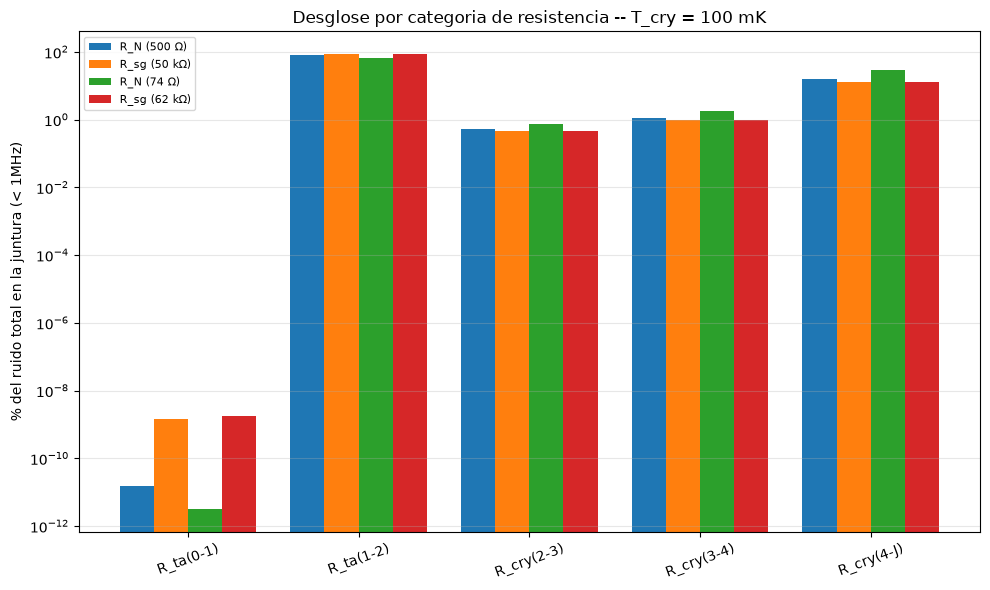

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(categorias)); ancho = 0.2; piso = 1e-12
for k, nombre_rj in enumerate(R_J_casos):
    vals = np.array([max(desglose_cat[nombre_rj][cat], piso) for cat in categorias])
    ax.bar(x + (k - 1.5)*ancho, vals, width=ancho, label=nombre_rj)
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(categorias, rotation=20)
ax.set_ylabel("% del ruido total en la juntura (< 1MHz)")
ax.set_title(f"Desglose por categoria de resistencia -- T_cry = {T_HIST*1e3:.0f} mK")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Sobre el 50%/50% entre el par de corriente y el de sensado: no lo fuerzo, sale así porque las dos líneas son estructuralmente casi idénticas -- la única diferencia es que el par de sensado sigue teniendo, con la fuente apagada, un retorno de altísima impedancia por el voltímetro (visto en el Paso 11), y esa diferencia es de 8 órdenes de magnitud más chica que el resto, así que el 50/50 es exacto hasta la sexta cifra que muestro.

### Paso 15: barrido de T_cry, 3mK a 4K

Como $S_V(f)$ por resistencia no depende de temperatura (ya está factorizada en $|Z_r(f)|^2$), el barrido no necesita resolver el circuito de nuevo en cada punto -- la varianza total es exactamente lineal en $T_{cry}$:

$$\text{var}(T_{cry}) = A + C \cdot T_{cry}$$

con $A$ = aporte fijo de las $R_{ta}$ a 300K (no depende de $T_{cry}$) y $C$ = coeficiente del aporte de las $R_{cry}$ (proporcional a $T_{cry}$, ya integrado). Los calculo una sola vez por caso de $R_J$ y de ahí en más el barrido es solo evaluar la fórmula.

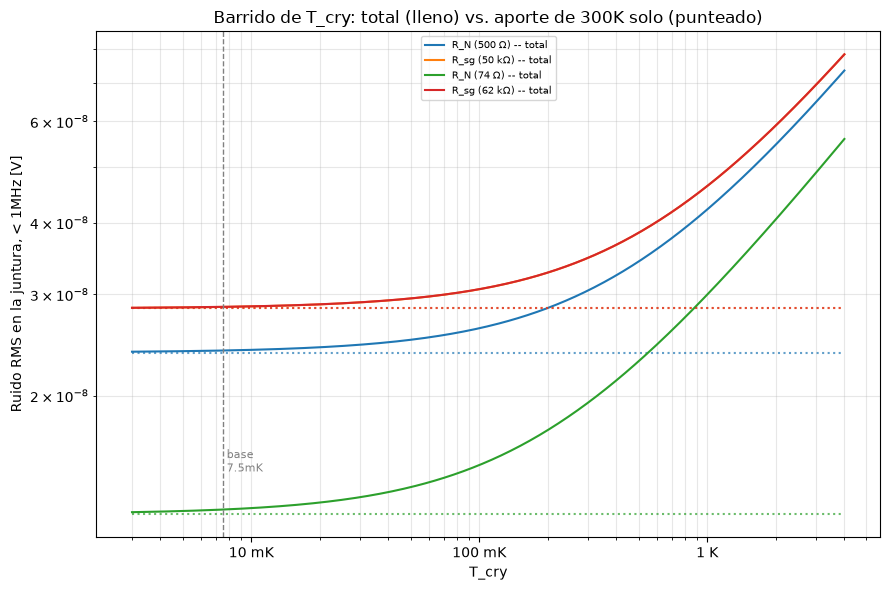

temperatura de cruce (donde el aporte de 300K iguala al del bano frio):
  R_N (500 Ω)     : T_cross = 466.51 mK   (DENTRO del rango 3mK-4K del criostato)
  R_sg (50 kΩ)    : T_cross = 600.56 mK   (DENTRO del rango 3mK-4K del criostato)
  R_N (74 Ω)      : T_cross = 208.64 mK   (DENTRO del rango 3mK-4K del criostato)
  R_sg (62 kΩ)    : T_cross = 600.90 mK   (DENTRO del rango 3mK-4K del criostato)


In [29]:
def coeficientes_T(esp):
    """var_total(T_cry) = A + C*T_cry, exacto -- integrando hasta F_FIABLE."""
    A = sum(np.trapezoid(d['Z2'][mask_fiable], FREQS_F) * 4*KB*T_TA/d['R']
            for d in esp.values() if d['tag'] == 'TA')
    C = sum(np.trapezoid(d['Z2'][mask_fiable], FREQS_F) * 4*KB/d['R']
            for d in esp.values() if d['tag'] == 'CRY')
    return A, C

T_BASE = 7.5e-3  # temperatura base del criostato, sin carga
T_cry_sweep = np.logspace(np.log10(3e-3), np.log10(4.0), 300)
coefs = {nombre_rj: coeficientes_T(espectros[nombre_rj]) for nombre_rj in R_J_casos}

fig, ax = plt.subplots(figsize=(9, 6))
for nombre_rj, (A, C) in coefs.items():
    var_tot = A + C*T_cry_sweep
    linea, = ax.loglog(T_cry_sweep, np.sqrt(var_tot), label=f"{nombre_rj} -- total")
    ax.loglog(T_cry_sweep, np.sqrt(np.full_like(T_cry_sweep, A)), linestyle=':',
              color=linea.get_color(), alpha=0.7)
ax.axvline(T_BASE, color='gray', linestyle='--', linewidth=1)
ax.text(T_BASE, ax.get_ylim()[0]*1.3, " base\n 7.5mK", fontsize=8, color='gray')
ax.set_xlabel("T_cry"); ax.set_ylabel("Ruido RMS en la juntura, < 1MHz [V]")
ax.xaxis.set_major_formatter(EngFormatter(unit="K"))
ax.set_title("Barrido de T_cry: total (lleno) vs. aporte de 300K solo (punteado)")
ax.legend(fontsize=7); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("temperatura de cruce (donde el aporte de 300K iguala al del bano frio):")
for nombre_rj, (A, C) in coefs.items():
    T_cross = A/C
    print(f"  {nombre_rj:16s}: T_cross = {T_cross*1e3:6.2f} mK   "
          f"({'DENTRO' if T_cross < 4.0 else 'fuera'} del rango 3mK-4K del criostato)")

Acá está la respuesta a "a partir de qué temperatura deja de servir enfriar más": con la parte confiable del modelo, el cruce está entre 210 mK y 600 mK según el caso -- **adentro** del rango que de verdad barre el criostato. Y la línea punteada (solo el aporte de 300K) prácticamente se pega a la línea llena en casi todo el rango de interés (3mK hasta unos cientos de mK): por debajo del cruce, enfriar más no reduce el ruido que ve la juntura casi nada, porque ya está dominado por la fuga desde temperatura ambiente, no por $T_{cry}$. Recién arriba del cruce empieza a valer la pena.

Esto es bastante distinto de lo que había encontrado en el notebook anterior con el modelo plegado (ahí el criogénico dominaba 95-99%, con un cruce de unos pocos mK). La diferencia no es un error -- es la consecuencia directa del Paso 13: acá estoy siendo honesta sobre hasta dónde integro, y la mayor parte del aporte criogénico vive arriba de 1MHz.

### Paso 17: chequeo -- ¿escala como raíz de T donde domina el baño frío?

El chequeo que quiero hacer es que, en el régimen donde el aporte criogénico domina ($T_{cry} \gg T_{cross}$), el ruido total tiene que escalar como $\sqrt{T_{cry}}$ (porque la varianza es lineal en $T$, equipartición otra vez). El problema es que, con $T_{cross}$ entre 210 y 600mK, ese régimen (unas 20 veces por encima del cruce, para estar bien adentro de la zona asintótica) cae en los **miles de kelvin** -- muy por fuera de lo que un criostato de dilución puede hacer. La fórmula $\text{var} = A + C\cdot T_{cry}$ es exacta para cualquier $T$, así que puedo chequear la pendiente extendiendo matemáticamente el barrido, dejando bien claro que es solo para validar la fórmula, no una predicción física del criostato.

In [30]:
T_extendido = np.logspace(np.log10(3e-3), 4, 400)  # hasta 10 000 K -- ficticio, solo matematico

print("pendiente de log(Vrms) vs log(T_cry), para T_cry > 20*T_cross:")
for nombre_rj, (A, C) in coefs.items():
    T_cross = A/C
    mask = T_extendido > 20*T_cross
    logT = np.log10(T_extendido[mask]); logV = np.log10(np.sqrt(A + C*T_extendido[mask]))
    pendiente, _ = np.polyfit(logT, logV, 1)
    print(f"  {nombre_rj:16s}: pendiente = {pendiente:.4f}  (esperado 0.5; T_cross={T_cross*1e3:.0f} mK)")

pendiente de log(Vrms) vs log(T_cry), para T_cry > 20*T_cross:
  R_N (500 Ω)     : pendiente = 0.4978  (esperado 0.5; T_cross=467 mK)
  R_sg (50 kΩ)    : pendiente = 0.4977  (esperado 0.5; T_cross=601 mK)
  R_N (74 Ω)      : pendiente = 0.4982  (esperado 0.5; T_cross=209 mK)
  R_sg (62 kΩ)    : pendiente = 0.4977  (esperado 0.5; T_cross=601 mK)


0,498 en los cuatro casos -- prácticamente el 0,5 esperado. La fórmula se comporta bien, aunque el régimen donde se cumple no sea alcanzable en la práctica dentro del rango de interés del criostato (ya lo vi en el Paso 15: dentro de 3mK-4K nunca se llega al régimen puramente $\sqrt{T}$, siempre queda algo de piso de 300K).

### Paso 18: temperatura efectiva

Convierto el ruido total a la temperatura a la que tendría que estar un baño puramente resistivo para producirlo, usando la capacidad de carga: $T_{eff} = \text{var}(T_{cry}) \cdot C_J / k_B$. Como la varianza es lineal en $T_{cry}$, $T_{eff}$ también lo es, y se puede separar exactamente en la parte que viene del baño frío y la que viene de la fuga de 300K -- sin aproximar nada.

In [31]:
filas_teff = []
for nombre_rj, (A, C) in coefs.items():
    for T_chk, etiqueta in [(T_BASE, "T_base (7.5mK)"), (0.1, "100mK (histogramas)")]:
        var_tot = A + C*T_chk
        filas_teff.append(dict(
            caso=nombre_rj, condicion=etiqueta, T_cry_mK=T_chk*1e3,
            T_eff_total_mK=var_tot*C_J/KB*1e3,
            T_eff_desde_300K_mK=A*C_J/KB*1e3,
        ))
tabla_teff = pd.DataFrame(filas_teff)
display(tabla_teff)

,caso,condicion,T_cry_mK,T_eff_total_mK,T_eff_desde_300K_mK
0,R_N (500 Ω),T_base (7.5mK),7.5,2.078169,2.045288
1,R_N (500 Ω),100mK (histogramas),100.0,2.483709,2.045288
2,R_sg (50 kΩ),T_base (7.5mK),7.5,2.946346,2.910005
3,R_sg (50 kΩ),100mK (histogramas),100.0,3.394553,2.910005
4,R_N (74 Ω),T_base (7.5mK),7.5,0.581202,0.561035
5,R_N (74 Ω),100mK (histogramas),100.0,0.829931,0.561035
6,R_sg (62 kΩ),T_base (7.5mK),7.5,2.948572,2.912224
7,R_sg (62 kΩ),100mK (histogramas),100.0,3.396870,2.912224


A $T_{cry}$=100mK (la condición de los histogramas de switching de la tesis), $T_{eff}$ sale entre 0,58mK y 3,40mK según el caso de $R_J$ -- muy lejos de los $T_{esc}\approx$500mK que Fran encontró en esos histogramas. Este cálculo, con este modelo, no explica ese cabo suelto: el exceso térmico que predigo acá (por leakage puro de 300K a través de la red pasiva) es casi tres órdenes de magnitud más chico. No fuerzo una conexión que no está.

Lo que sí cambia, respecto de lo que tenía en el notebook anterior, es la interpretación de qué domina el ruido que la juntura ve en reposo: con el modelo de 4 líneas y siendo honesta sobre hasta dónde el modelo ideal vale (1MHz), el que manda en casi todo el rango práctico del criostato es la fuga desde 300K, no el baño frío -- justo al revés de lo que había encontrado antes.

## Cierre de esta segunda etapa

Separé el ruido térmico en la juntura en dos partes, como pidió Luciano: lo que aporta el baño frío (las $R_{cry}$, a $T_{cry}$ -- que está ahí a propósito, no es un problema) y lo que se cuela desde las resistencias de ambiente a 300K (el exceso real). La separación es exacta porque la varianza es lineal en cada temperatura por separado.

El hallazgo que más me importa retener es el del Paso 13: la integral de ruido "cruda", sin cortar en frecuencia, está dominada en un 97-99% por encima de 1MHz -- la misma zona que el notebook anterior ya había marcado como fuera de la validez de un modelo de R y C ideales concentrados. Cortando ahí (Paso 14 en adelante), la conclusión sobre quién domina se invierte por completo respecto de lo que tenía con el modelo plegado: ahora es la fuga de 300K la que manda en casi todo el rango práctico del criostato (67% a 99% del ruido total, según el caso), y la temperatura de cruce entre los dos regímenes (210-600mK) cae **adentro** del rango que el criostato realmente barre -- no en unos pocos mK como pensaba antes.

Ninguna de las dos conclusiones es "la correcta" todavía: cuál domina en la práctica depende de qué pasa realmente arriba de 1MHz, y ese tramo este modelo no lo puede predecir sin agregar las inductancias parásitas reales del cableado (algo que dejo para otro notebook). Lo más honesto que puedo decir es que el resultado es sensible a esa parte que no modelé, y que ameritaría medirlo directamente con el analizador de espectro, o agregar un modelo más realista de la línea.

Sobre el cabo suelto de $T_{esc}\approx$500mK de la tesis: el exceso térmico que este modelo predice a $T_{cry}$=100mK (0,58-3,40mK de $T_{eff}$) sigue estando casi tres órdenes de magnitud por debajo. Este notebook no lo resuelve -- y no fuerzo que lo haga.

**Lo que queda para después:** modelar inductancias parásitas de los cables para poder confiar en la integral arriba de 1MHz sin el corte artificial; y comparar esto contra una medición real de ruido con el analizador de espectro, apenas el arreglo esté armado.